# Data Loading

Import the required libraries and load the Titanic dataset.

In [74]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [75]:
import seaborn as sns

titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Data Exploration

Investigate the structure of the dataset and identify missing values before building the model.

In [76]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [77]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [78]:
titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


# Data Cleaning

Select the variables used for modelling, handle missing values, and convert categorical variables into numerical format.

In [79]:
data = titanic[[
    'survived',
    'pclass',
    'sex',
    'age',
    'sibsp',
    'parch',
    'fare'
]].copy()

Missing values were identified in the age variable (177 missing observations).

These missing values were replaced using the median age because the median is less sensitive to extreme values than the mean and provides a simple way to retain observations for modelling.

In [80]:
data['age'] = data['age'].fillna(data['age'].median())

In [81]:
data.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0


Machine learning models require numerical inputs.

The categorical variable "sex" was therefore encoded as:

- Male = 0
- Female = 1

In [82]:
data['sex'] = data['sex'].map({
    'male':0,
    'female':1
})

In [83]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare
0,0,3,0,22.0,1,0,7.2500
1,1,1,1,38.0,1,0,71.2833
2,1,3,1,26.0,0,0,7.9250
3,1,1,1,35.0,1,0,53.1000
4,0,3,0,35.0,0,0,8.0500


# Model Training

Split the data into training and testing sets, then train a Decision Tree classifier.

In [84]:
y = data['survived']

In [85]:
X = data.drop('survived', axis=1)

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [87]:
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train);

In [88]:
preds = model.predict(X_test)

# Model Evaluation

Assess model performance using prediction accuracy and identify the most influential variables.

In [89]:
accuracy = accuracy_score(y_test, preds)

print("Accuracy:", accuracy)

Accuracy: 0.7988826815642458


In [90]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
1,sex,0.605737
0,pclass,0.209536
2,age,0.075353
5,fare,0.061240
3,sibsp,0.048135
4,parch,0.000000


# Decision Tree Visualisation

Visualise the trained decision tree to understand how the model makes predictions.

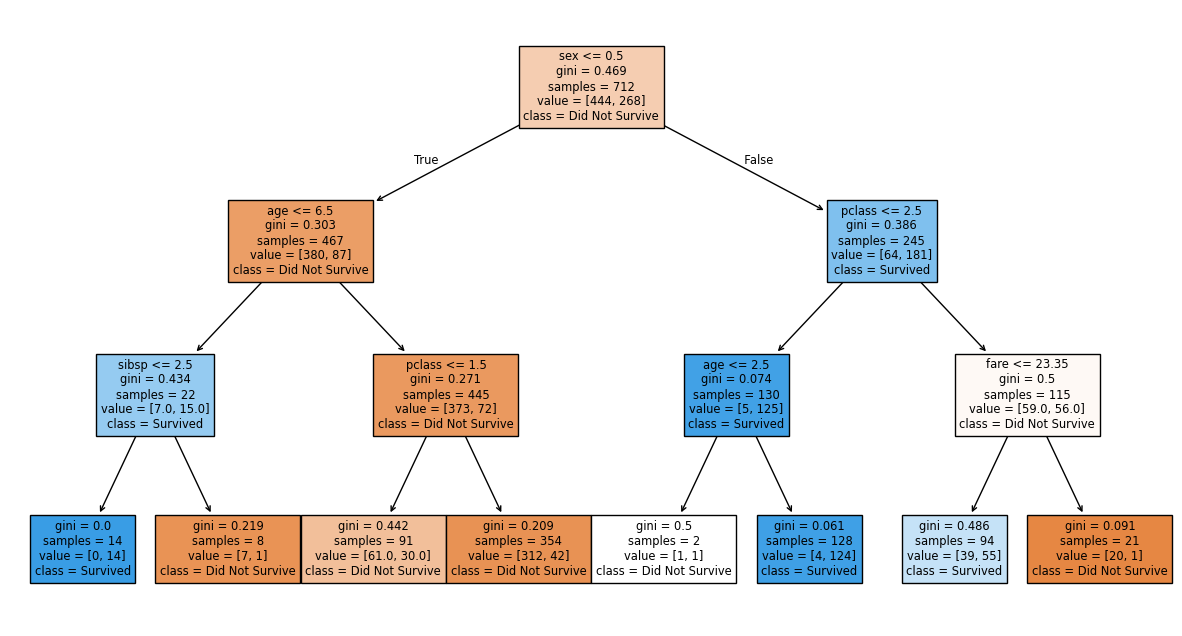

In [91]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Did Not Survive','Survived'],
    filled=True
)

plt.show()

# Conclusion

The Decision Tree model achieved approximately 79.9% accuracy when predicting survival on unseen passengers.

The most influential variables were passenger sex, ticket class, age, and fare.

The model showed that female passengers and those travelling in higher classes generally had a greater chance of survival.

This project demonstrated the complete machine learning workflow, including data exploration, data cleaning, feature preparation, model training, and model evaluation.

It also highlighted the importance of data quality and preprocessing when building predictive models.